# 🧪 ML Experiment Tracker – Quant Researcher
**Workflow**: Feature Load → Model Training → SHAP Interpretability → MLflow Logging → Model Comparison

---

In [1]:
from qtrader.output.analyst import AnalystSession, RoleContext
from qtrader.input.features.store import FeatureStore
import polars as pl
import numpy as np
from scipy.special import erfinv
import plotly.express as px
import plotly.graph_objects as go
import shap
import matplotlib.pyplot as plt

session = AnalystSession(role=RoleContext.RESEARCHER)

SYMBOL   = 'BTC-USD'
TIMEFRAME = '1d'
TARGET   = 'fwd_ret_1'
EXPERIMENT = 'qtrader_alpha_research'
TEST_FRAC = 0.2

# Plotly Dark Theme Config
PLOTLY_DARK = dict(template="plotly_dark", plot_bgcolor='#0f1117', paper_bgcolor='#0f1117')

## 1. Feature Loading
Pulling pre-computed technical factors from the `FeatureStore`.

In [2]:
df = session.load_features(SYMBOL, TIMEFRAME)

if df.is_empty():
    print("⚠️  FeatureStore empty. Generating data...")
    df = session.sample_ohlcv(symbol='BTC', days=365)
    df = session.make_returns(df)
    df = session.add_rolling_features(df)
    df = session.run_alpha_score(df, forward_periods=[1, 5])
    df = df.drop_nulls()

feature_cols = [c for c in df.columns if c.startswith(('sma_', 'vol_', 'rsi_', 'avg_'))]
print(f"Experimenting with {len(feature_cols)} features on {TARGET}")
df.head()

DuckDB unavailable (IO Error: Could not set lock on file "/Users/hoangnam/qtrader/notebooks/researcher/qtrader.db": Conflicting lock is held in /opt/homebrew/Cellar/python@3.10/3.10.19_1/Frameworks/Python.framework/Versions/3.10/Resources/Python.app/Contents/MacOS/Python (PID 42430) by user hoangnam. See also https://duckdb.org/docs/stable/connect/concurrency); using Parquet fallback.
No features found for BTC-USD/1d – run feature engine first.
⚠️ DATA_SOURCE: Generating SYNTHETIC data for BTC.


⚠️  FeatureStore empty. Generating data...
Experimenting with 9 features on fwd_ret_1


timestamp,open,high,low,close,volume,returns,sma_5,vol_5,sma_14,vol_14,sma_21,vol_21,avg_gain,avg_loss,rsi_14,fwd_ret_1,fwd_ret_5,alpha_score
datetime[μs],f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-01-01 00:20:00,99.803149,99.83981,99.758402,99.815167,1828,0.001664,99.802556,0.095929,100.117302,0.288231,100.140689,0.243189,0.000251,0.000645,27.975973,-0.000412,0.00027,-0.000071
2025-01-01 00:21:00,99.780616,99.828308,99.747221,99.773995,2695,-0.000412,99.786129,0.091387,100.069629,0.285684,100.126532,0.25576,0.000199,0.000675,22.773068,0.000575,-0.001411,-0.000418
2025-01-01 00:22:00,99.787354,99.846406,99.69997,99.831376,6774,0.000575,99.771765,0.071968,100.028343,0.274347,100.116054,0.263385,0.00024,0.000652,26.911975,-0.001752,0.000657,-0.000548
2025-01-01 00:23:00,99.645182,99.703209,99.640964,99.656471,4465,-0.001752,99.745275,0.086901,99.971235,0.261389,100.094486,0.281854,0.000207,0.000777,21.025807,-0.000653,-0.000606,-0.000629
2025-01-01 00:24:00,99.590937,99.650887,99.514271,99.591434,1265,-0.000653,99.733688,0.104887,99.914587,0.250653,100.062369,0.299237,0.000207,0.000773,21.116368,0.00027,-0.00022,0.000025


## 2. Walk-Forward Split
Maintaining time-series integrity by avoiding random splits.

In [7]:
valid_df = df.select(feature_cols + [TARGET]).drop_nulls()
n = len(valid_df)
split = int(n * (1 - TEST_FRAC))
train_df = valid_df.head(split)
test_df  = valid_df.tail(n - split)

X_train, y_train = train_df.select(feature_cols).to_numpy(), train_df[TARGET].to_numpy()
X_test, y_test   = test_df.select(feature_cols).to_numpy(), test_df[TARGET].to_numpy()
print(f"Train subset: {X_train.shape} | Test subset: {X_test.shape}")

Train subset: (6988, 9) | Test subset: (1747, 9)


## 3. Training & MLflow Tracking
Logging architecture, hyperparams, and Information Coefficient (IC).

In [8]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

mlflow.set_experiment(EXPERIMENT)

params = {'n_estimators': 150, 'max_depth': 5, 'min_samples_leaf': 10}

with mlflow.start_run(run_name=f"{SYMBOL}_RF_Alpha") as run:
    model = RandomForestRegressor(**params, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    ic = float(np.corrcoef(preds, y_test)[0, 1])

    mlflow.log_params(params)
    mlflow.log_metrics({'MAE': mae, 'IC': ic})
    mlflow.sklearn.log_model(model, "model")

    print(f"Training Complete. IC: {ic:.4f} | MAE: {mae:.6f}")

2026/03/16 17:19:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/16 17:19:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Training Complete. IC: 0.0268 | MAE: 0.000858
🏃 View run BTC-USD_RF_Alpha at: http://localhost:5050/#/experiments/1/runs/201ac491485140a99942613cd43e376c
🧪 View experiment at: http://localhost:5050/#/experiments/1


## 4. SHAP Interpretability
Understanding which features drive the model's predictions.

Global Feature Importance via SHAP:


/var/folders/h9/_37f97bx28q57hg0p4dlwxcc0000gn/T/ipykernel_42559/423191673.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_cols, plot_type="bar", show=False)


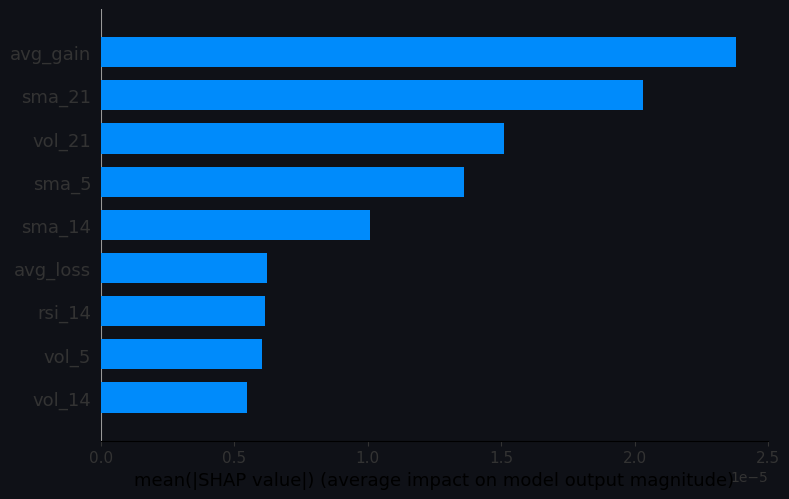

In [9]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("Global Feature Importance via SHAP:")
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, plot_type="bar", show=False)
plt.gcf().set_facecolor('#0f1117')
plt.gca().set_facecolor('#0f1117')
plt.show()

## 5. Model Analytics
Visualizing prediction vs reality and historical run performance.

In [10]:
# 1. Prediction Scatter
fig_scat = px.scatter(
    x=y_test, y=preds,
    labels={'x': 'Actual Returns', 'y': 'Predicted Alpha'},
    title="Actual vs Predicted Return (Test Set)",
    trendline="ols",
    trendline_color_override="#ef4444"
)
fig_scat.update_layout(**PLOTLY_DARK)
fig_scat.show()

# 2. Historical IC Comparison
runs = mlflow.search_runs(experiment_names=[EXPERIMENT])
if not runs.empty:
    fig_runs = px.bar(
        runs.sort_values('metrics.IC', ascending=False).head(10),
        x='run_id', y='metrics.IC',
        title="Experiment Leaderboard: Information Coefficient (IC)",
        color='metrics.IC', color_continuous_scale='Viridis'
    )
    fig_runs.update_layout(**PLOTLY_DARK, xaxis_tickangle=-45)
    fig_runs.show()